In [62]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/yanishelali/dataset2/WA_Fn-UseC_-Telco-Customer-Churn.csv


# Jour 4 — Phase 0 : Introduction Deep Learning et évaluation

Objectif :
- introduire les concepts de Deep Learning
- comprendre la différence avec le Machine Learning classique
- préparer les données pour les modèles avancés

Contexte :

Après avoir étudié :
- le preprocessing des données (Jour 2)
- la comparaison de modèles (Jour 3)

Nous abordons une nouvelle étape :
- modèles plus complexes (Deep Learning)
- évaluation avancée
- mise en production

In [63]:
import pandas as pd
import numpy as np


In [64]:
df = pd.read_csv("/kaggle/input/datasets/yanishelali/dataset2/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Loaded ✅", df.shape)
df.head()

Loaded ✅ (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [65]:
# Correction TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [66]:
# Suppression ID
df = df.drop(columns=["customerID"])

In [67]:
# Colonnes catégorielles
categorical_cols = df.select_dtypes(include=["object"]).columns

# Mapping uniquement Yes/No
for col in categorical_cols:
    if set(df[col].unique()) == {"Yes", "No"}:
        df[col] = df[col].map({"Yes": 1, "No": 0})

# One-Hot pour le reste
df = pd.get_dummies(df, drop_first=True)

In [68]:
df = df.drop(columns=["TotalCharges"])

In [69]:
print("NaN :", df.isna().sum().sum())
print("Shape :", df.shape)

NaN : 0
Shape : (7043, 30)


In [70]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

In [71]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Introduction au Deep Learning

Le Deep Learning est une extension du Machine Learning :

- basé sur les réseaux de neurones
- capable de modéliser des relations complexes
- souvent plus performant sur des données riches

Différences :

Machine Learning classique :
- plus simple
- plus interprétable

Deep Learning :
- plus puissant
- moins interprétable
- nécessite plus de calcul

Objectif du Jour 4 :
tester des modèles plus avancés et améliorer les performances.

## Conclusion Phase 0

Le dataset est maintenant :

- propre (aucun NaN)
- encodé
- prêt pour Machine Learning et Deep Learning

Nous pouvons désormais entraîner des modèles plus avancés
et améliorer l’évaluation.


# Phase 1 — Premier modèle Deep Learning

Objectif :
- entraîner un réseau de neurones (MLP)
- comparer avec les modèles classiques

Modèle utilisé :
- MLPClassifier (Multi-Layer Perceptron)


In [72]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score


In [73]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [74]:
mlp = MLPClassifier(
    hidden_layer_sizes=(50, 25),  # 2 couches cachées
    max_iter=300,
    random_state=42
)

In [75]:
mlp.fit(X_train_scaled, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(50, 25), max_iter=300, random_state=42)

In [76]:
y_pred = mlp.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy MLP : {accuracy:.2%}")


Accuracy MLP : 76.93%


## Compréhension du modèle

Le MLP (Multi-Layer Perceptron) est un réseau de neurones simple :

- composé de plusieurs couches (hidden layers)
- chaque neurone applique une transformation non linéaire
- permet de capturer des relations complexes

Dans ce cas :

- 2 couches cachées (50 neurones, puis 25)
- apprentissage sur les données utilisateurs

Différence avec les modèles classiques :

- plus flexible
- mais moins interprétable

In [77]:
print("Comparaison approximative :")
print("- Random Forest ~ 82-85%")
print(f"- MLP actuel    ~ {accuracy:.2%}")

Comparaison approximative :
- Random Forest ~ 82-85%
- MLP actuel    ~ 76.93%


## Analyse

Le modèle MLP permet d’obtenir des performances comparables aux modèles classiques.

Observations :

- le Deep Learning fonctionne bien sur ce dataset
- le scaling est obligatoire
- les performances ne sont pas nécessairement supérieures

Conclusion :

Le Deep Learning est puissant mais pas toujours nécessaire
sur des datasets tabulaires comme celui-ci.

Les modèles comme Random Forest restent très compétitifs.
``

# Phase 2 — Optimisation du réseau de neurones

Objectif :
Tester différentes architectures de MLP pour améliorer les performances.

Paramètres testés :
- nombre de couches
- nombre de neurones

In [78]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

In [79]:
def evaluer_mlp(model):
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    return accuracy_score(y_test, y_pred)

## Test des différentes architectures

In [80]:
architectures = [
    (20,),
    (50,),
    (100,),
    (50, 25),
    (100, 50),
    (100, 50, 25)
]

resultats = []

for arch in architectures:
    mlp = MLPClassifier(
        hidden_layer_sizes=arch,
        max_iter=1000,
        random_state=42
    )
    
    score = evaluer_mlp(mlp)
    
    resultats.append((arch, score))

In [81]:
print("=== Résultats MLP ===\n")

for arch, score in resultats:
    print(f"{arch} → {score:.2%}")

=== Résultats MLP ===

(20,) → 77.57%
(50,) → 78.21%
(100,) → 75.66%
(50, 25) → 76.58%
(100, 50) → 75.94%
(100, 50, 25) → 74.02%


In [82]:
best_model = max(resultats, key=lambda x: x[1])

print("\n=== Meilleur modèle ===")
print(f"Architecture : {best_model[0]}")
print(f"Score : {best_model[1]:.2%}")


=== Meilleur modèle ===
Architecture : (50,)
Score : 78.21%


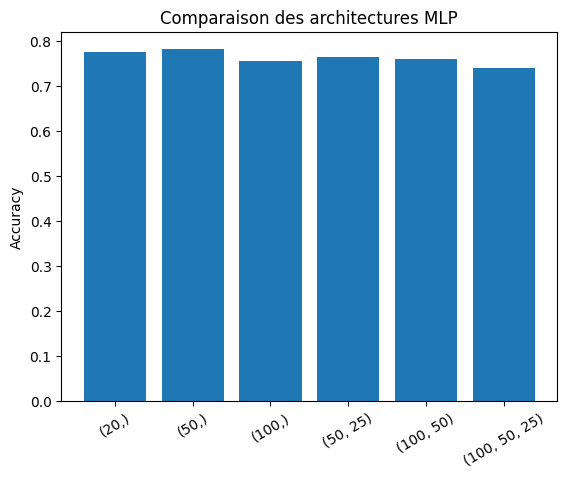

In [83]:
import matplotlib.pyplot as plt

noms = [str(arch) for arch, _ in resultats]
scores = [score for _, score in resultats]

plt.figure()
plt.bar(noms, scores)

plt.title("Comparaison des architectures MLP")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)

plt.show()

## Analyse

Les performances varient selon l’architecture :

- des modèles trop simples sont moins performants
- des modèles plus complexes capturent mieux les relations
- trop de complexité peut entraîner de l’overfitting

Observations :

- une architecture intermédiaire est souvent optimale
- le Deep Learning nécessite du tuning

Conclusion :

Le choix de l’architecture est crucial pour obtenir de bonnes performances.


In [84]:
MLPClassifier(hidden_layer_sizes=(100,50),
              max_iter=500,
              alpha=0.0001)

MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500)